In [1]:
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_csv('../data/heart_disease.csv')

In [3]:
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [4]:
X = df.drop("Heart Disease",axis = 1)

In [5]:
numerical_features = X.select_dtypes(include=["int64","float64"]).columns
categorical_features = X.select_dtypes(include = "str").columns

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

preprocessor = ColumnTransformer(
    transformers = [
        ("num",StandardScaler(),numerical_features),
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ]
)

X_processed = preprocessor.fit_transform(X)

if(hasattr(X_processed,"toarray")):
    X_processed = X_processed.toarray()

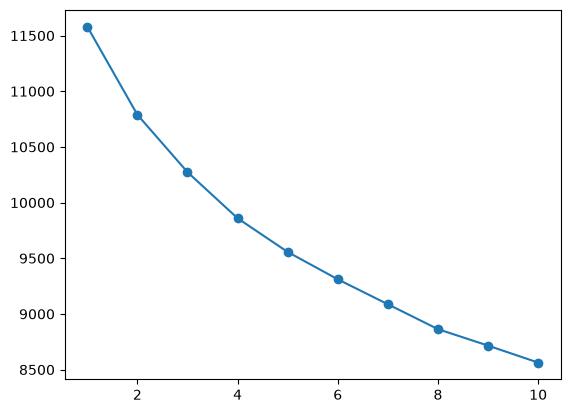

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,11):
    model = KMeans(
        n_clusters=k,
        n_init=10
    )

    model.fit(X_processed)

    inertia.append(model.inertia_)

plt.plot(range(1,11),inertia,marker='o')
plt.show()



In [17]:
best_k = 3

best_model = KMeans(
    n_clusters = best_k,
    n_init = 10
)

clusters = best_model.fit_predict(X_processed)

df['Cluster'] = clusters

In [19]:
print(df['Cluster'].value_counts())

Cluster
2    378
0    337
1    285
Name: count, dtype: int64


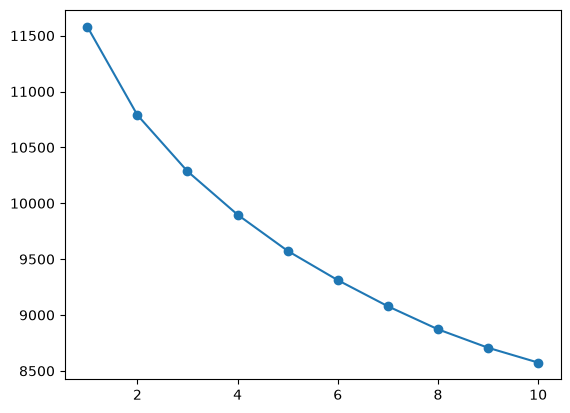

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,11):
    model = KMeans(
        n_clusters = k,
        n_init = 10
    )

    model.fit(X_processed)

    inertia.append(model.inertia_)


plt.plot(range(1,11),inertia,marker='o')
plt.show()



In [21]:
optimal_k = 3

best_model = KMeans(
    n_clusters = optimal_k,
    n_init = 10
)

clusters = best_model.fit_predict(X_processed)

df["cluster"] = clusters

print(df["cluster"].value_counts())

cluster
0    368
1    338
2    294
Name: count, dtype: int64


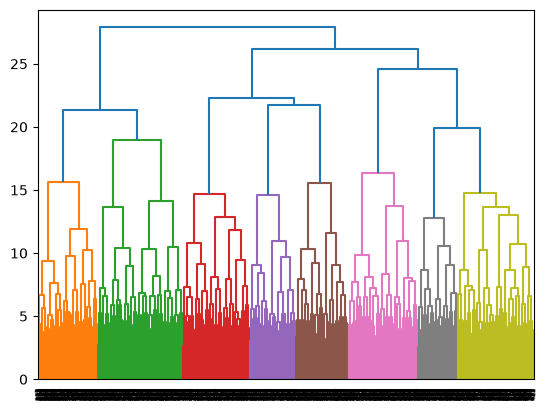

In [23]:
from scipy.cluster.hierarchy import linkage,dendrogram

linked = linkage(X_processed,method="ward")
dendrogram(linked)

plt.show()

In [26]:
from sklearn.cluster import DBSCAN

model_db = DBSCAN(
    eps = 1.5,
    min_samples=5
)

clusters_db = model.fit_predict(X_processed)

df['clusters_db'] = clusters_db

print(df["clusters_db"].value_counts())

clusters_db
-1    1000
Name: count, dtype: int64
